In [1]:
!pip install pmdarima
import pandas as pd
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima


Defaulting to user installation because normal site-packages is not writeable


In [2]:

df = pd.read_csv(r"C:\Users\HP\Documents\Data Analysis portfolio\Raw Datasets\household_power_consumption.txt", sep = ';',na_values = '?')
       


In [3]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
#find out if there are duplicates in the data
df.duplicated().sum()

np.int64(0)

In [5]:
#combine date and time into one
df["Date_Time"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    dayfirst = True,
    errors = "coerce")

In [6]:
df = df.drop(columns=["Date" , "Time"])

In [7]:
#make datetime the index
df = df.set_index("Date_Time")
df = df.sort_index()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000


In [10]:
#find out percentage of missing values
df.isnull().sum()/len(df) * 100

Global_active_power      1.251844
Global_reactive_power    1.251844
Voltage                  1.251844
Global_intensity         1.251844
Sub_metering_1           1.251844
Sub_metering_2           1.251844
Sub_metering_3           1.251844
dtype: float64

In [11]:
print("Final shape after cleaning:" , {df.shape})

Final shape after cleaning: {(2075259, 7)}


In [12]:
#resampling data to hourly frequency using mean
df_hourly = df['Global_active_power'].resample('h').mean()

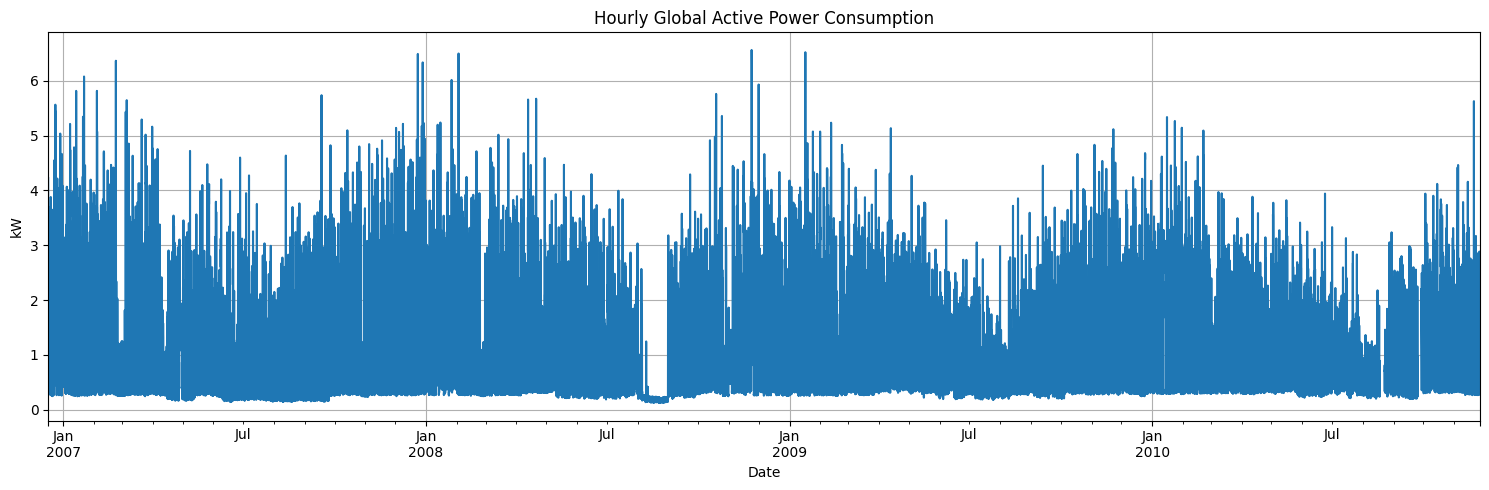

In [13]:
#plot hourly energy consumption
plt.figure(figsize = (15,5))
df_hourly.plot()

plt.title("Hourly Global Active Power Consumption")
plt.xlabel("Date")
plt.ylabel("kW")
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
#the decomposition plot
#resample to daily average
daily_data = df['Global_active_power'].resample('D').mean()

In [15]:
#drop rows with missing values
daily_data = daily_data.dropna()

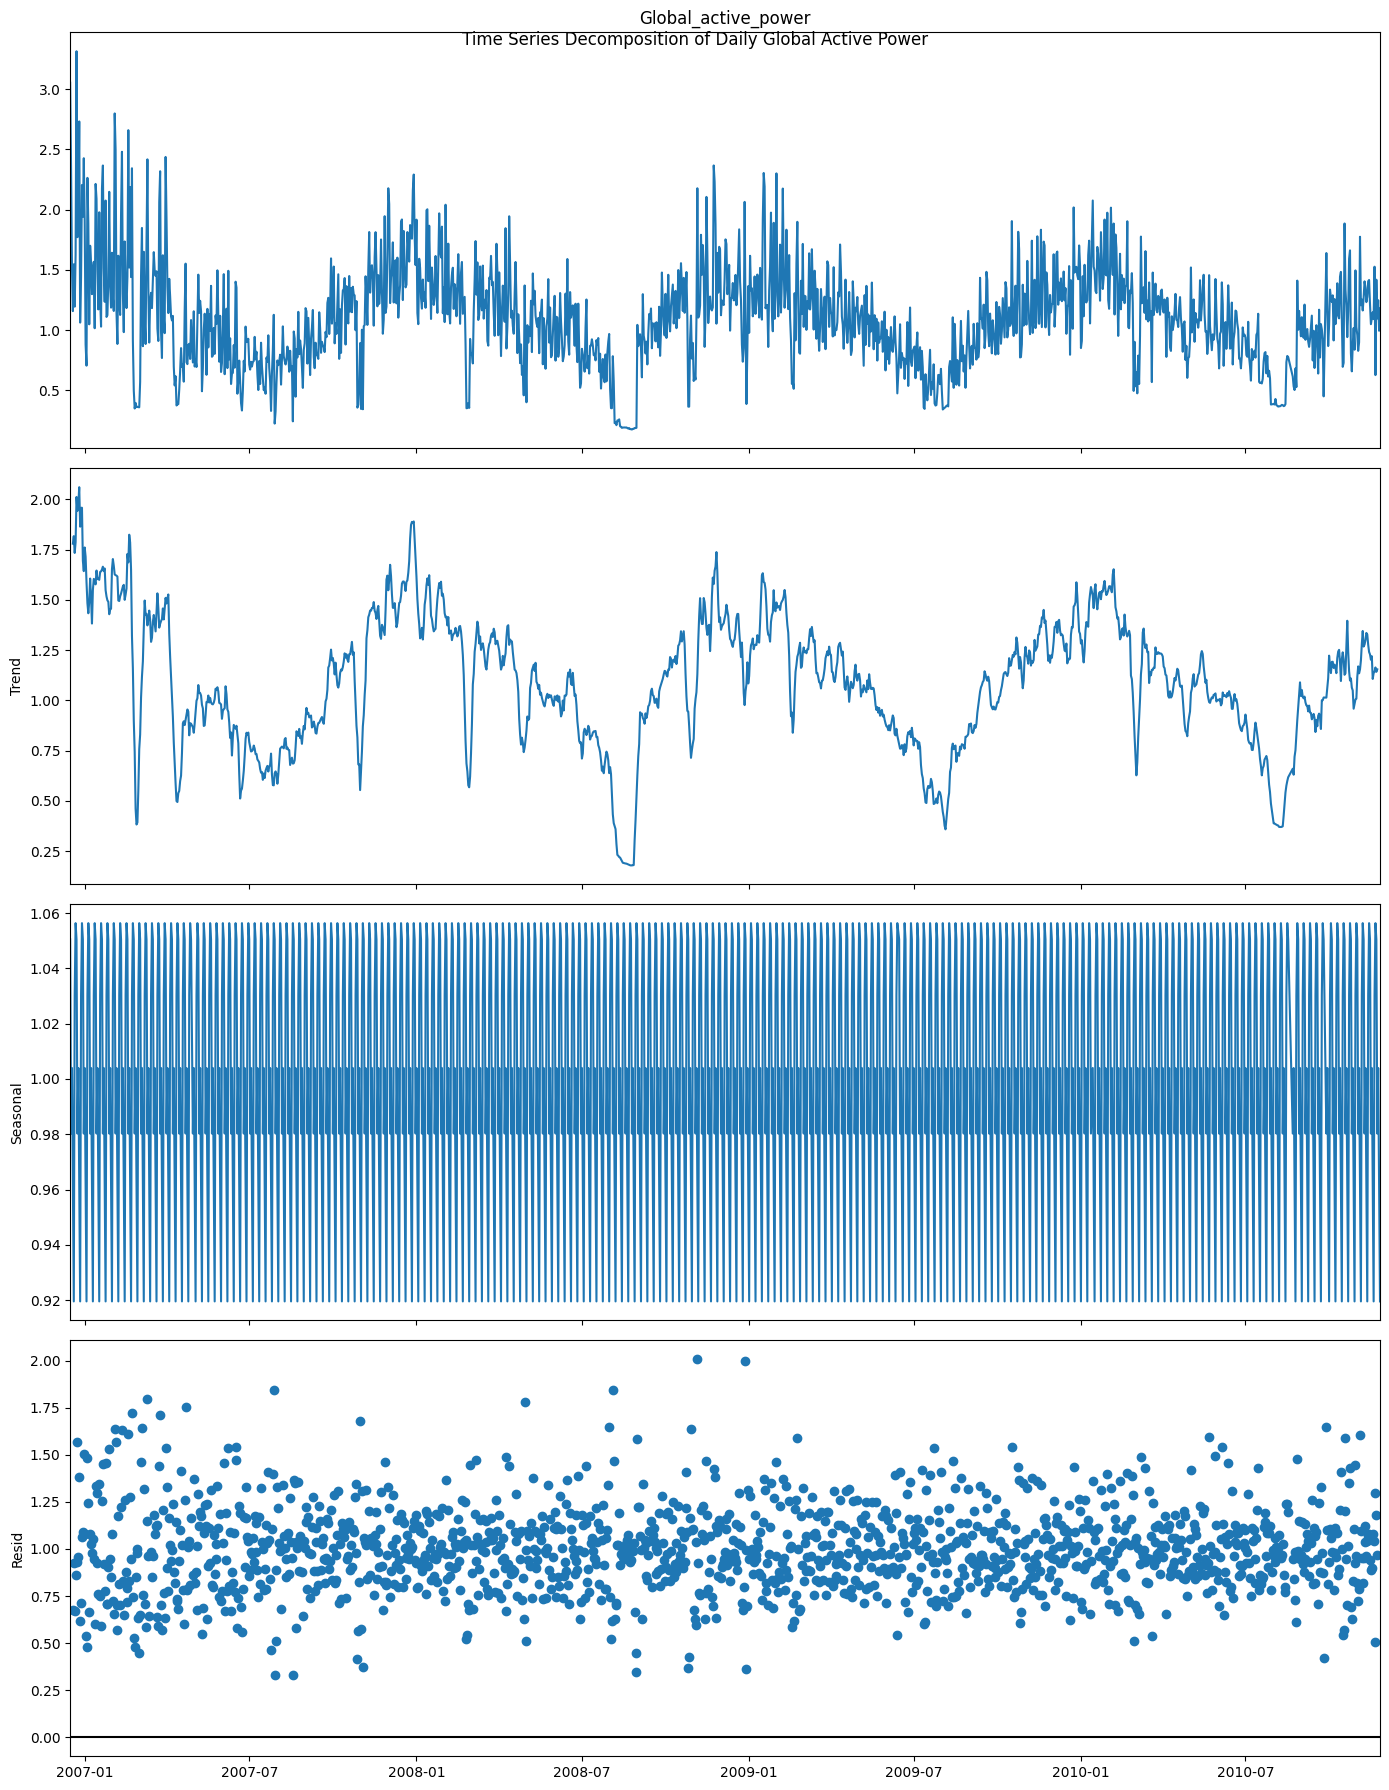

In [16]:
#decomposing the time series
decomposition = seasonal_decompose(daily_data, model = 'multiplicative', period = 7)

plt.rcParams.update({'figure.figsize' : (14,18)})
decomposition.plot()
plt.suptitle('Time Series Decomposition of Daily Global Active Power')
plt.show()

<Axes: >

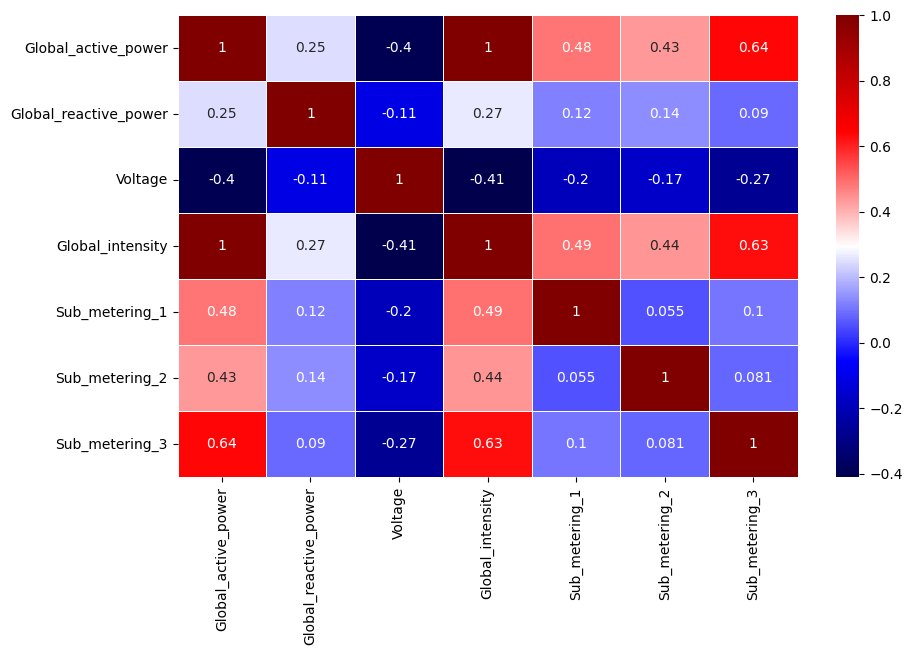

In [18]:
plt.figure(figsize =(10,6))
sns.heatmap(df.corr(), annot = True, cmap = 'seismic', linewidth = 0.5)


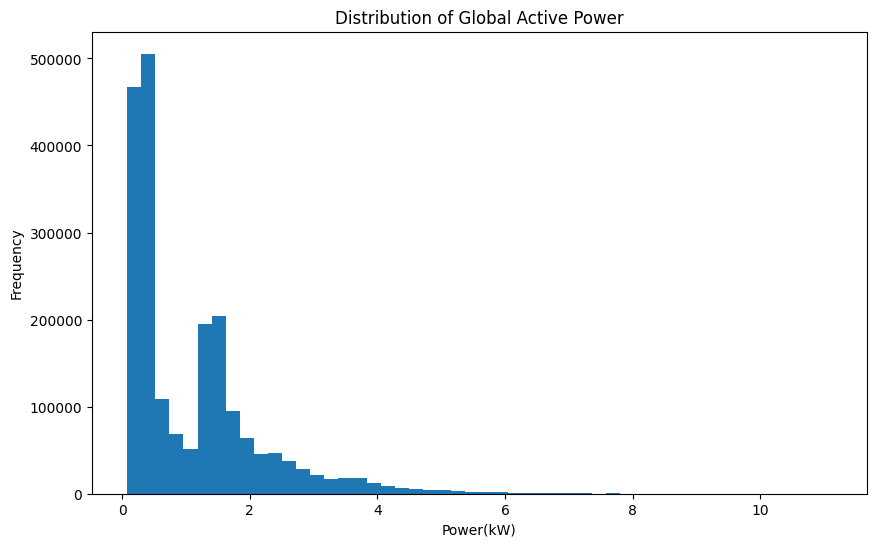

In [19]:
#distribution of energy consumption
plt.figure(figsize = (10,6))
plt.hist(df['Global_active_power'], bins = 50)
plt.title("Distribution of Global Active Power")
plt.xlabel("Power(kW)")
plt.ylabel("Frequency")

plt.show()

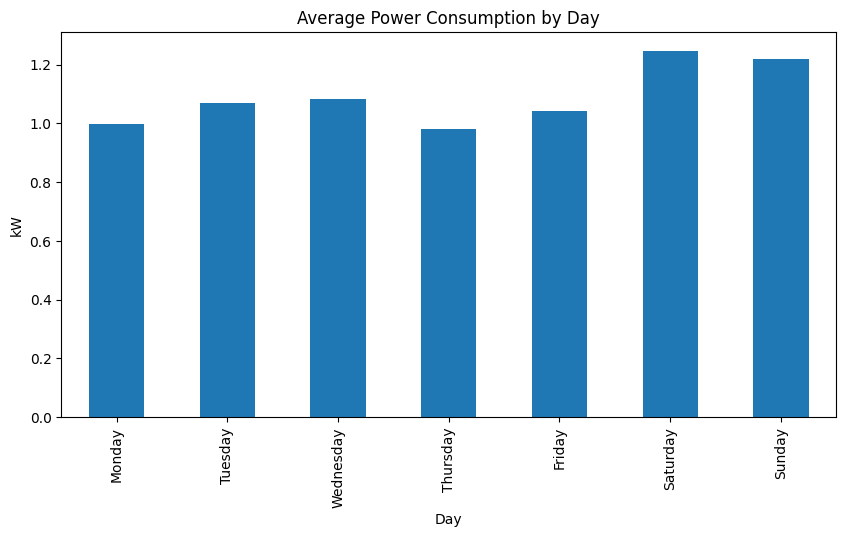

In [20]:
#daily power consumption
df['Day'] = df.index.day_name()
daily_avg = df.groupby('Day')['Global_active_power'].mean()
daily_avg = daily_avg.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
daily_avg.plot( kind = 'bar', figsize = (10,5))
plt.title("Average Power Consumption by Day")
plt.ylabel("kW")
plt.show()

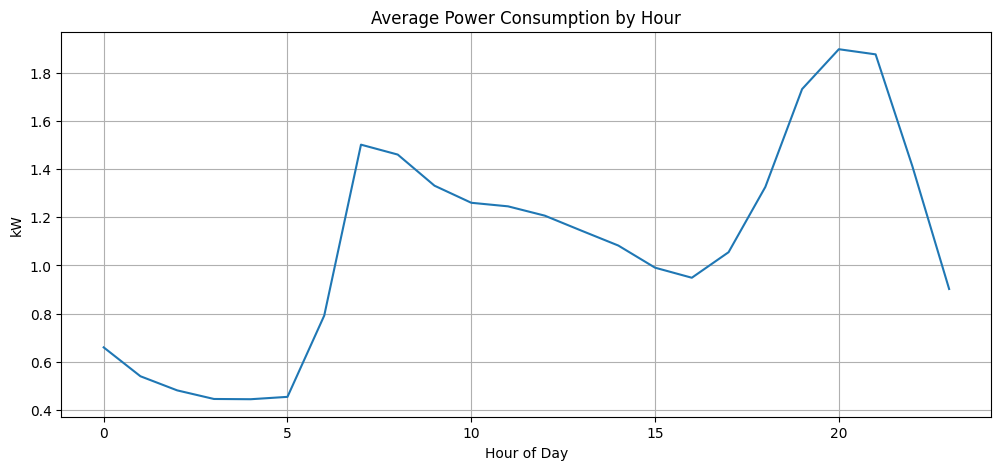

In [21]:
#hourly consumption rate
df['Hour'] = df.index.hour
hourly_avg = df.groupby('Hour')['Global_active_power'].mean()

hourly_avg.plot(figsize=(12,5))
plt.title("Average Power Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("kW")
plt.grid(True)

plt.show()

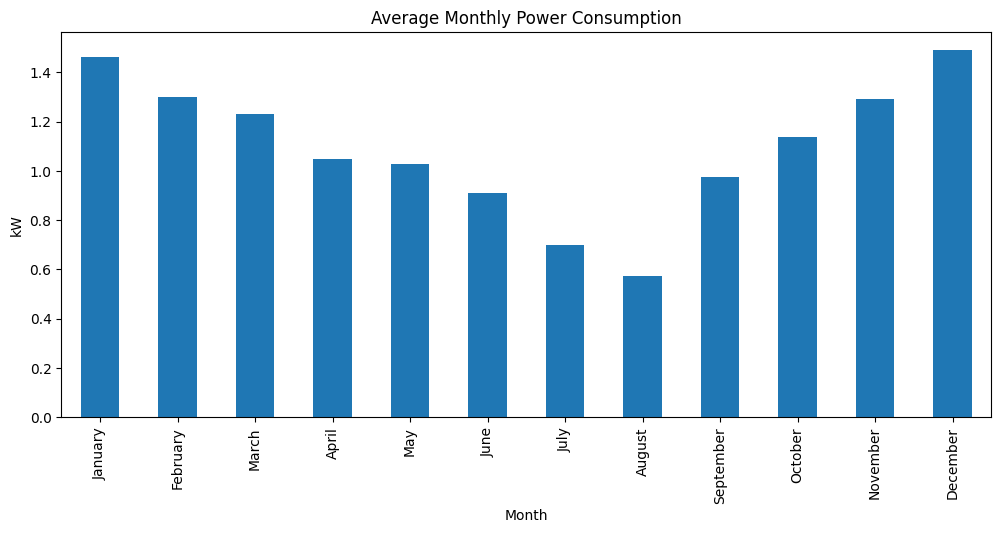

In [22]:
#monthly energy consumption
df['Month'] = df.index.month_name()
monthly_avg = df.groupby('Month')['Global_active_power'].mean()
monthly_avg = monthly_avg.reindex(['January','February','March','April','May','June','July','August','September','October','November','December'])

monthly_avg.plot(kind='bar', figsize=(12,5))
plt.title("Average Monthly Power Consumption")
plt.ylabel("kW")
plt.show()

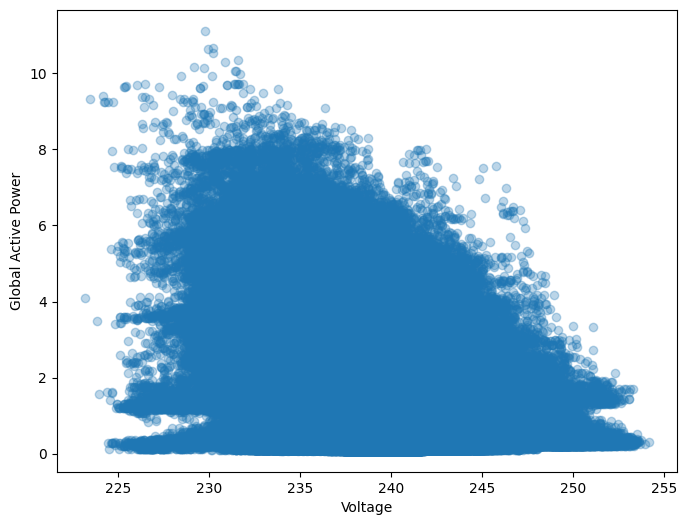

In [23]:
#voltage vs power consumption scatter plot
plt.figure(figsize=(8,6))

plt.scatter(df['Voltage'],df['Global_active_power'],alpha = 0.3)
plt.xlabel("Voltage")
plt.ylabel("Global Active Power")
plt.show()

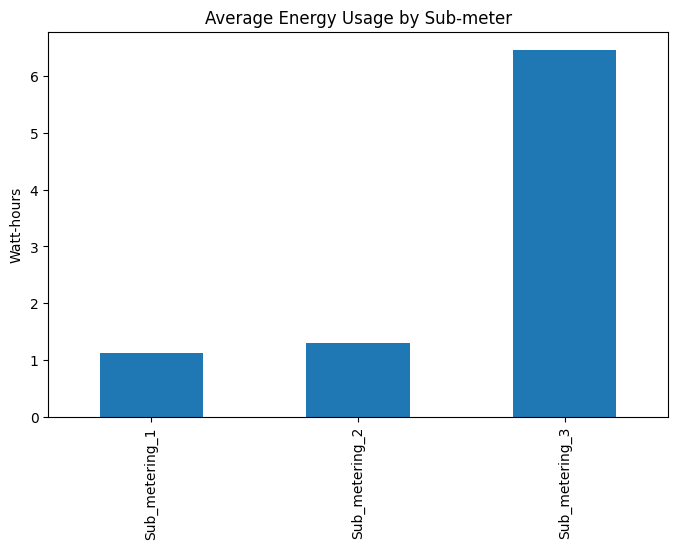

In [24]:
#energy sub-metering comparison
submeters = df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].mean()

submeters.plot(kind='bar', figsize=(8,5))
plt.title("Average Energy Usage by Sub-meter")
plt.ylabel("Watt-hours")
plt.show()

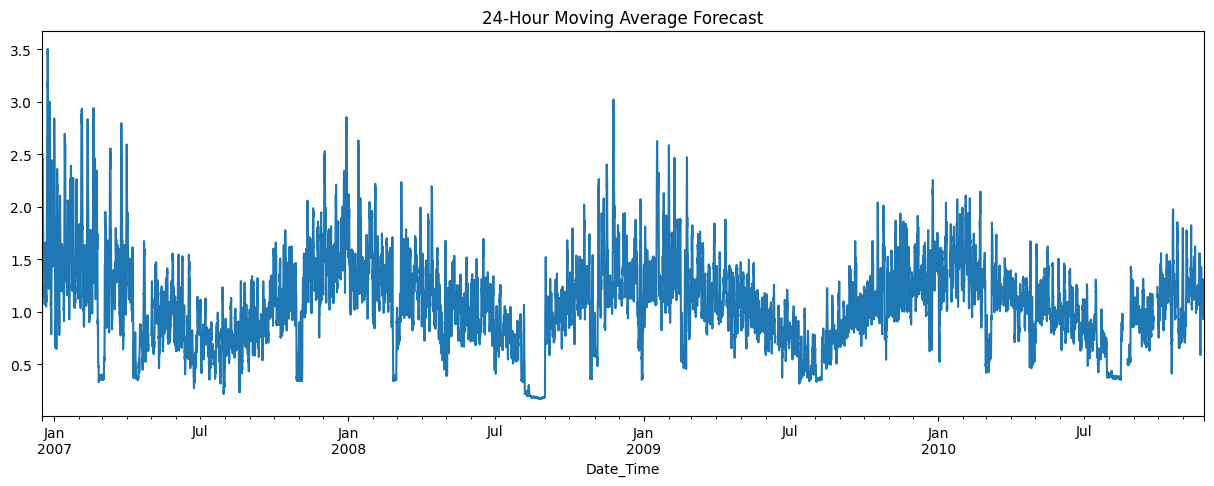

In [25]:
#moving average 
df
forecast =(df_hourly.rolling(24).mean())
forecast.plot(figsize = (15,5))
plt.title("24-Hour Moving Average Forecast")
plt.show()